Шаг 1 и 2: Загрузка, слияние и генерация признаков

In [11]:
# [Ячейка 1: Импорт библиотек]
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Установим опцию, чтобы видеть все колонки
pd.set_option('display.max_columns', None)

In [12]:
# [Ячейка 2: Загрузка данных]
# Читаем большой файл. Parquet загрузит 7 млн строк за секунды.
df = pd.read_parquet('clean_3_with_weather.parquet')

# Читаем результаты кластеризации (из файла, сохраненного в твоем ноутбуке)
clusters_df = pd.read_csv('8_zone_clusters_mapping.csv')

print(f"Размер исходного датасета: {df.shape}")

Размер исходного датасета: (7655312, 34)


In [13]:
# [Ячейка 3: Добавление кластеров]
# Нам нужно присоединить кластеры дважды: для точки старта и для точки финиша.

# 1. Присоединяем кластер для точки отправления (PULocationID)
df = df.merge(
    clusters_df.rename(columns={'PULocationID': 'PULocationID', 'cluster_id': 'PU_cluster'}),
    on='PULocationID',
    how='left'
)

# 2. Присоединяем кластер для точки прибытия (DOLocationID)
# У нас в clusters_df колонка называется PULocationID, поэтому для DOLocationID мы ее временно переименуем в merge
df = df.merge(
    clusters_df.rename(columns={'PULocationID': 'DOLocationID', 'cluster_id': 'DO_cluster'}),
    on='DOLocationID',
    how='left'
)

# Если есть пропуски в кластерах (вдруг появились новые зоны), заполним их маркером "-1"
df['PU_cluster'] = df['PU_cluster'].fillna(-1).astype(int)
df['DO_cluster'] = df['DO_cluster'].fillna(-1).astype(int)

In [14]:
print(f"Размер нового датасета: {df.shape}")

Размер нового датасета: (7655312, 36)


In [15]:
# [Ячейка 4: Feature Engineering - Время]
# Убедимся, что колонка со временем в формате datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Извлекаем признаки из времени, которые сильно влияют на пробки и скорость
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek # 0 - Пн, 6 - Вс
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# Можно добавить бинарный флаг выходного дня
df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

In [16]:
print(f"Размер нового нового датасета: {df.shape}")

Размер нового нового датасета: (7655312, 40)


Шаг 3: Подготовка признаков и разбиение данных
Нам нужно выделить целевую переменную (таргет) и признаки, а затем разделить датасет на тренировочную и тестовую части.

In [17]:
# [Ячейка 5: Подготовка X и y]
# Целевая переменная (убедись, что колонка называется именно так)
target = 'duration_min' 

# Наши признаки (фичи): только время и локации
features = [
    'PULocationID', 'DOLocationID', # Точные зоны
    'PU_cluster', 'DO_cluster',     # Макро-регионы (кластеры)
    'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend' # Время
]

X = df[features]
y = df[target]

# Указываем, какие колонки являются категориальными. 
# Для CatBoost это критически важно: он под капотом использует Target Encoding 
# и отлично работает с категориями без раздувания датасета через One-Hot Encoding.
cat_features = ['PULocationID', 'DOLocationID', 'PU_cluster', 'DO_cluster', 'pickup_dayofweek', 'pickup_month', 'is_weekend']

# Замечание: pickup_hour можно оставить как числовой признак, 
# но часто перевод его в категорию дает прирост качества, так как зависимость пробок от часа нелинейная.
cat_features.append('pickup_hour')

# Приводим все категориальные фичи к типу int (или string), чтобы CatBoost не ругался
for col in cat_features:
    X[col] = X[col].astype(int)

In [18]:
# [Ячейка 6: Сплит датасета]
from sklearn.model_selection import train_test_split

# Разбиваем данные: 80% на обучение, 20% на тест.
# random_state фиксируем для воспроизводимости результатов.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (6124249, 8)
Размер тестовой выборки: (1531063, 8)


Шаг 4: Обучение CatBoost
Ментор дал отличный совет. CatBoost строит ансамбль решающих деревьев (градиентный бустинг). Он будет последовательно создавать деревья, где каждое новое дерево пытается исправить ошибки всех предыдущих.

In [19]:
# [Ячейка 7: Инициализация и обучение модели]
from catboost import CatBoostRegressor

# Настраиваем параметры модели
model = CatBoostRegressor(
    iterations=1000,          # Количество деревьев (эпох). Можно увеличить, если есть время.
    learning_rate=0.1,        # Шаг обучения. Меньше шаг -> дольше учится, но точнее результат.
    depth=6,                  # Глубина каждого дерева. 6-8 обычно оптимально для таких задач.
    loss_function='RMSE',     # Функция потерь, которую модель минимизирует. RMSE сильно штрафует за грубые ошибки.
    eval_metric='MAE',        # Метрика для оценки в процессе (Mean Absolute Error - ошибка в минутах).
    random_seed=42,
    task_type='CPU'           # Если есть мощная видеокарта от NVIDIA, можно поменять на 'GPU'
)

# Запускаем обучение
# eval_set позволяет модели проверять себя на тестовой выборке каждую эпоху.
# early_stopping_rounds остановит обучение, если качество на тесте не улучшается 50 шагов подряд (защита от переобучения).
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    verbose=100,              # Выводить лог каждые 100 итераций
    early_stopping_rounds=50
)

0:	learn: 8.9751926	test: 8.9664092	best: 8.9664092 (0)	total: 4.62s	remaining: 1h 16m 55s
100:	learn: 4.2618042	test: 4.1974485	best: 4.1974485 (100)	total: 3m 40s	remaining: 32m 45s
200:	learn: 4.1463551	test: 4.0776002	best: 4.0776002 (200)	total: 7m 24s	remaining: 29m 26s
300:	learn: 4.0944589	test: 4.0266987	best: 4.0266987 (300)	total: 11m 6s	remaining: 25m 48s
400:	learn: 4.0615789	test: 3.9951304	best: 3.9951304 (400)	total: 14m 46s	remaining: 22m 4s
500:	learn: 4.0374696	test: 3.9727256	best: 3.9727256 (500)	total: 18m 41s	remaining: 18m 37s
600:	learn: 4.0204347	test: 3.9563628	best: 3.9563628 (600)	total: 22m 43s	remaining: 15m 5s
700:	learn: 4.0082603	test: 3.9458479	best: 3.9458479 (700)	total: 26m 51s	remaining: 11m 27s
800:	learn: 3.9971540	test: 3.9355939	best: 3.9355939 (800)	total: 30m 38s	remaining: 7m 36s
900:	learn: 3.9879512	test: 3.9269617	best: 3.9269617 (900)	total: 34m 25s	remaining: 3m 46s
999:	learn: 3.9797545	test: 3.9193372	best: 3.9193372 (999)	total: 38m

CatBoostRegressor(depth=6, eval_metric='MAE', iterations=1000, learning_rate=0.1, loss_function='RMSE', random_seed=42, task_type='CPU')

Шаг 5: Оценка результатов и анализ
После обучения нужно понять, насколько хорошо мы предсказываем и на что модель обращает больше всего внимания. MAE (Mean Absolute Error) покажет нам среднюю ошибку в минутах. Если MAE = 3, значит, в среднем мы ошибаемся на 3 минуты, что для такси очень хороший результат.

In [24]:
# [Ячейка 8: Метрики качества (Обновленная)]
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Делаем предсказания на тестовой выборке
y_pred = model.predict(X_test)

# Считаем метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Метрики качества модели ---")
print(f"MAE (Средняя абсолютная ошибка): {mae:.2f} минут")
print(f"RMSE (Корень из среднеквадратичной ошибки): {rmse:.2f} минут")
print(f"R² (Коэффициент детерминации): {r2:.4f}")

--- Метрики качества модели ---
MAE (Средняя абсолютная ошибка): 3.92 минут
RMSE (Корень из среднеквадратичной ошибки): 6.28 минут
R² (Коэффициент детерминации): 0.7802


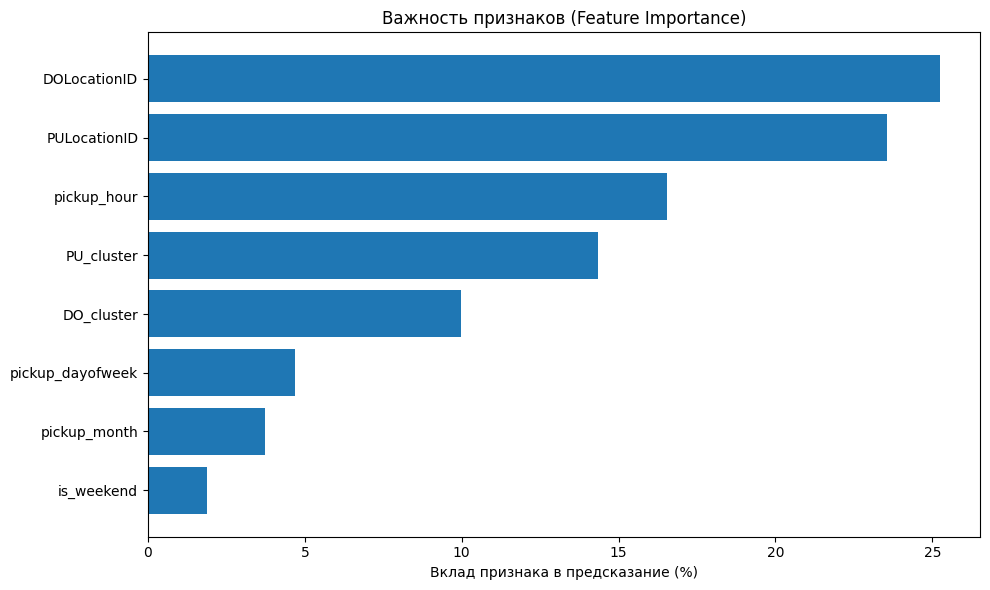

In [21]:
# [Ячейка 9: Важность признаков (Feature Importance)]
import matplotlib.pyplot as plt

# Достаем важность признаков из обученной модели
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('Важность признаков (Feature Importance)')
plt.xlabel('Вклад признака в предсказание (%)')
plt.tight_layout()
plt.show()

In [22]:
# [Ячейка 10: Средняя продолжительность в исходных данных]
# Посчитаем среднее и медиану, чтобы понимать общую картину
mean_duration = df['duration_min'].mean()
median_duration = df['duration_min'].median()

print(f"--- Статистика исходных данных ---")
print(f"Средняя продолжительность поездки: {mean_duration:.2f} минут")
print(f"Медианная продолжительность поездки: {median_duration:.2f} минут")

--- Статистика исходных данных ---
Средняя продолжительность поездки: 16.64 минут
Медианная продолжительность поездки: 12.90 минут


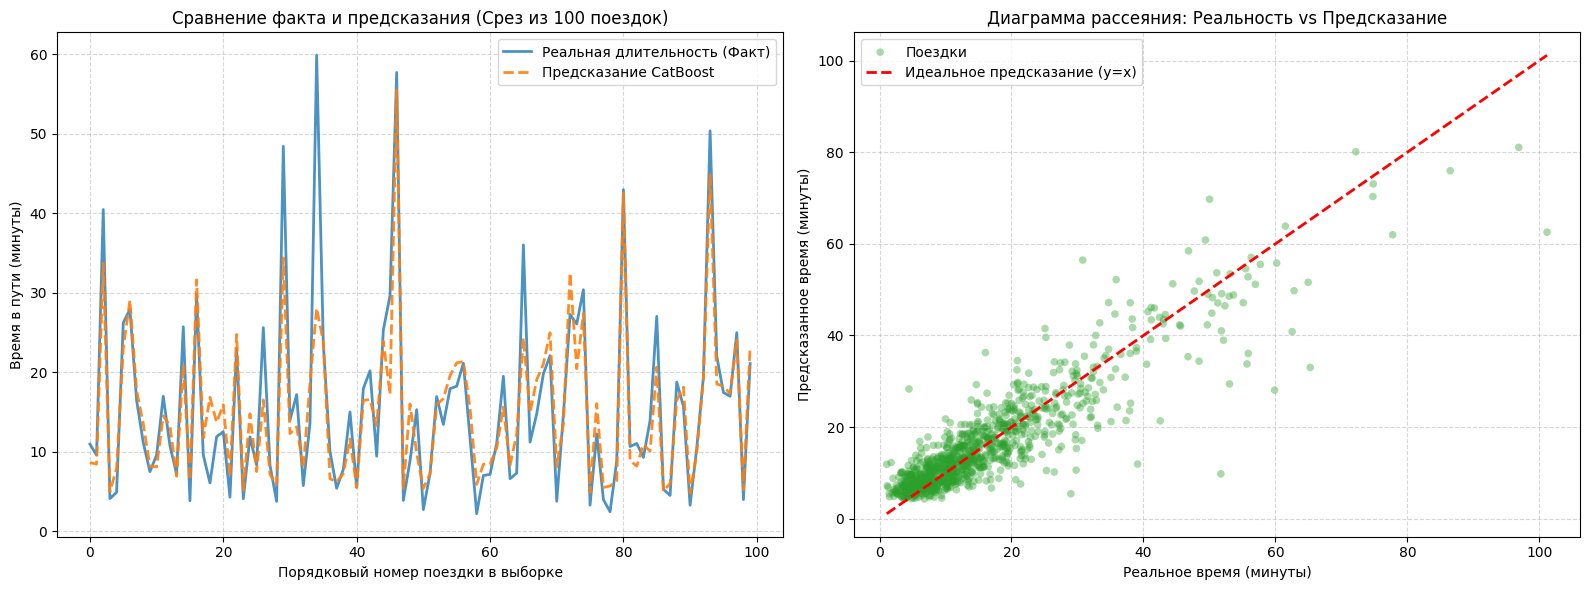

In [23]:
# [Ячейка 11: Визуализация предсказаний и правильных ответов]
import matplotlib.pyplot as plt
import numpy as np

# Фиксируем сид и берем случайные 1000 точек из тестовой выборки для визуализации
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), size=1000, replace=False)

# Если y_test это Pandas Series, используем .iloc, если массив - обычные индексы
y_test_sample = y_test.iloc[sample_indices].values if hasattr(y_test, 'iloc') else y_test[sample_indices]
y_pred_sample = y_pred[sample_indices]

# Настраиваем размер полотна для двух графиков
plt.figure(figsize=(16, 6))

# --- ГРАФИК 1: Линейное сравнение (визуальный тренд) ---
# Для наглядности возьмем первые 100 точек из нашего сэмпла, чтобы линии не сливались
plt.subplot(1, 2, 1)
plt.plot(y_test_sample[:100], label='Реальная длительность (Факт)', color='#1f77b4', alpha=0.8, linewidth=2)
plt.plot(y_pred_sample[:100], label='Предсказание CatBoost', color='#ff7f0e', alpha=0.9, linestyle='--', linewidth=2)
plt.title('Сравнение факта и предсказания (Срез из 100 поездок)')
plt.xlabel('Порядковый номер поездки в выборке')
plt.ylabel('Время в пути (минуты)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# --- ГРАФИК 2: Диаграмма рассеяния (Scatter Plot) ---
# Показывает распределение ошибок по всей длине таргета для 1000 поездок
plt.subplot(1, 2, 2)
plt.scatter(y_test_sample, y_pred_sample, color='#2ca02c', alpha=0.4, edgecolors='none', s=30, label='Поездки')

# Рисуем идеальную линию y = x. Если модель идеальна — все точки будут лежать на ней
max_val = max(y_test_sample.max(), y_pred_sample.max())
min_val = min(y_test_sample.min(), y_pred_sample.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Идеальное предсказание (y=x)')

plt.title('Диаграмма рассеяния: Реальность vs Предсказание')
plt.xlabel('Реальное время (минуты)')
plt.ylabel('Предсказанное время (минуты)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()